## 1. Environment Setup & Imports

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc
)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2. Model Architecture Definitions

In [15]:
class SimpleCNN(nn.Module):
    """SimpleCNN: 3 convolutional layers with minimal regularization."""
    def __init__(self, num_classes=2, img_size=224):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*(img_size//8)*(img_size//8), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Model architectures defined.")

Model architectures defined.


## 3. Dataset Preparation

In [16]:
IMG_SIZE = 224
BATCH_SIZE_SIMPLECNN = 32  # SimpleCNN trained with batch size 32
BATCH_SIZE_RESNET = 16     # ResNet50 trained with batch size 16

# SimpleCNN uses dataset-specific normalization
simplecnn_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.2793528744310471, 0.27950309053311284, 0.27967727192441916], 
                         [0.2559729772422186, 0.25598504036208913, 0.2560580670754761])
])

# ResNet50 uses ImageNet normalization
resnet_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset paths
test_dir = "../dataset_processed/test"

# Create datasets
test_dataset_simplecnn = datasets.ImageFolder(test_dir, transform=simplecnn_transform)
test_dataset_resnet = datasets.ImageFolder(test_dir, transform=resnet_transform)

# DataLoaders with model-specific batch sizes
test_loader_simplecnn = DataLoader(test_dataset_simplecnn, batch_size=BATCH_SIZE_SIMPLECNN, shuffle=False, num_workers=4)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE_RESNET, shuffle=False, num_workers=4)

print(f"Test dataset size: {len(test_dataset_simplecnn)}")
print(f"Class mapping: {test_dataset_simplecnn.class_to_idx}")

Test dataset size: 450
Class mapping: {'no': 0, 'yes': 1}


## 4. Load Pre-trained Models

In [17]:
# Load SimpleCNN
print("Loading SimpleCNN...")
simplecnn = SimpleCNN(num_classes=2, img_size=IMG_SIZE).to(device)
simplecnn_checkpoint = torch.load("../cnn/best_model.pth", map_location=device)
simplecnn.load_state_dict(simplecnn_checkpoint['model_state'])
print(f"SimpleCNN loaded with {sum(p.numel() for p in simplecnn.parameters())} parameters")

# Load ResNet50
print("\nLoading ResNet50...")
resnet50 = models.resnet50(weights=None)
num_features = resnet50.fc.in_features
resnet50.fc = nn.Linear(num_features, 2)
resnet50 = resnet50.to(device)
resnet50_checkpoint = torch.load("../resnet/resnet50_best.pth", map_location=device)
resnet50.load_state_dict(resnet50_checkpoint)
print(f"ResNet50 loaded with {sum(p.numel() for p in resnet50.parameters())} parameters")

Loading SimpleCNN...
SimpleCNN loaded with 6446498 parameters

Loading ResNet50...
ResNet50 loaded with 23512130 parameters


## 5. Model Evaluation Function

In [18]:
def evaluate_model(model, loader, model_name, device):
    """Evaluate model on test set and return comprehensive metrics."""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)[:, 1]
            preds = outputs.argmax(dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Convert to numpy arrays
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    auc_score = roc_auc_score(all_labels, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=['No Tumor', 'Tumor'], digits=4)
    
    # ROC curve data
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    
    # Additional metrics from confusion matrix
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
    
    print("="*60)
    print(f"{model_name} - Test Results")
    print("="*60)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"AUC: {auc_score:.4f}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nClassification Report:")
    print(report)
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'auc': auc_score,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision,
        'f1': f1,
        'confusion_matrix': cm,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    }

print("Evaluation function defined.")

Evaluation function defined.


## 6. Evaluate Both Models

In [19]:
# Evaluate SimpleCNN
simplecnn_results = evaluate_model(simplecnn, test_loader_simplecnn, "SimpleCNN", device)

print("\n")

# Evaluate ResNet50
resnet50_results = evaluate_model(resnet50, test_loader_resnet, "ResNet50", device)

SimpleCNN - Test Results
Accuracy: 0.9844
AUC: 0.9993
Sensitivity (Recall): 0.9778
Specificity: 0.9911
Precision: 0.9910
F1-Score: 0.9843

Confusion Matrix:
[[223   2]
 [  5 220]]

Classification Report:
              precision    recall  f1-score   support

    No Tumor     0.9781    0.9911    0.9845       225
       Tumor     0.9910    0.9778    0.9843       225

    accuracy                         0.9844       450
   macro avg     0.9845    0.9844    0.9844       450
weighted avg     0.9845    0.9844    0.9844       450



ResNet50 - Test Results
Accuracy: 0.9978
AUC: 1.0000
Sensitivity (Recall): 1.0000
Specificity: 0.9956
Precision: 0.9956
F1-Score: 0.9978

Confusion Matrix:
[[224   1]
 [  0 225]]

Classification Report:
              precision    recall  f1-score   support

    No Tumor     1.0000    0.9956    0.9978       225
       Tumor     0.9956    1.0000    0.9978       225

    accuracy                         0.9978       450
   macro avg     0.9978    0.9978    0.9978   

## 7. Comparison Summary Table

In [20]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['SimpleCNN', 'ResNet50'],
    'Accuracy': [simplecnn_results['accuracy'], resnet50_results['accuracy']],
    'AUC': [simplecnn_results['auc'], resnet50_results['auc']],
    'Sensitivity': [simplecnn_results['sensitivity'], resnet50_results['sensitivity']],
    'Specificity': [simplecnn_results['specificity'], resnet50_results['specificity']],
    'Precision': [simplecnn_results['precision'], resnet50_results['precision']],
    'F1-Score': [simplecnn_results['f1'], resnet50_results['f1']],
    'False_Negatives': [simplecnn_results['fn'], resnet50_results['fn']],
    'False_Positives': [simplecnn_results['fp'], resnet50_results['fp']]
})

print("\n" + "="*60)
print("SIDE-BY-SIDE COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Save comparison
comparison_df.to_csv('model_comparison_metrics.csv', index=False)
print("\nComparison table saved to: model_comparison_metrics.csv")


SIDE-BY-SIDE COMPARISON
    Model  Accuracy      AUC  Sensitivity  Specificity  Precision  F1-Score  False_Negatives  False_Positives
SimpleCNN  0.984444 0.999289     0.977778     0.991111   0.990991  0.984340                5                2
 ResNet50  0.997778 0.999980     1.000000     0.995556   0.995575  0.997783                0                1

Comparison table saved to: model_comparison_metrics.csv


## 8. Visualization: ROC Curves Comparison

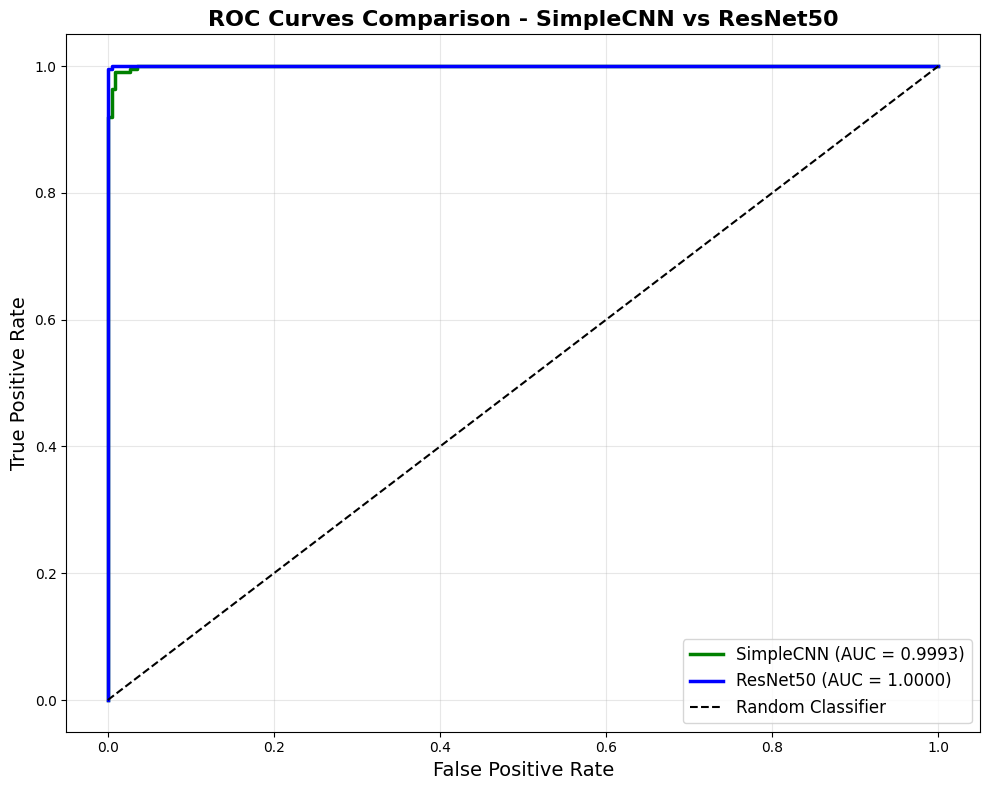

Saved: roc_curve_comparison.png


In [21]:
plt.figure(figsize=(10, 8))
plt.plot(simplecnn_results['fpr'], simplecnn_results['tpr'], 
         label=f"SimpleCNN (AUC = {simplecnn_results['roc_auc']:.4f})", 
         color='green', lw=2.5)
plt.plot(resnet50_results['fpr'], resnet50_results['tpr'], 
         label=f"ResNet50 (AUC = {resnet50_results['roc_auc']:.4f})", 
         color='blue', lw=2.5)
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curves Comparison - SimpleCNN vs ResNet50', fontsize=16, fontweight='bold')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: roc_curve_comparison.png")

## 9. Visualization: Confusion Matrices

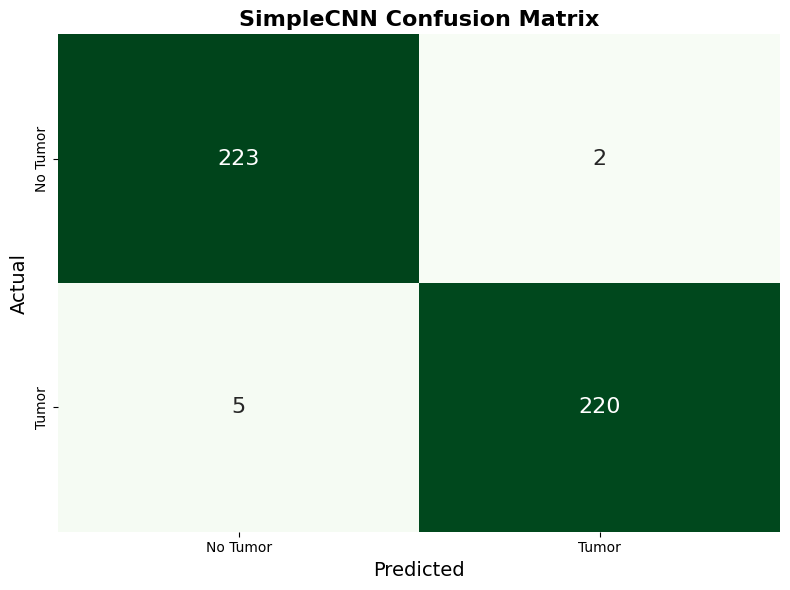

Saved: confusion_matrix_simplecnn.png


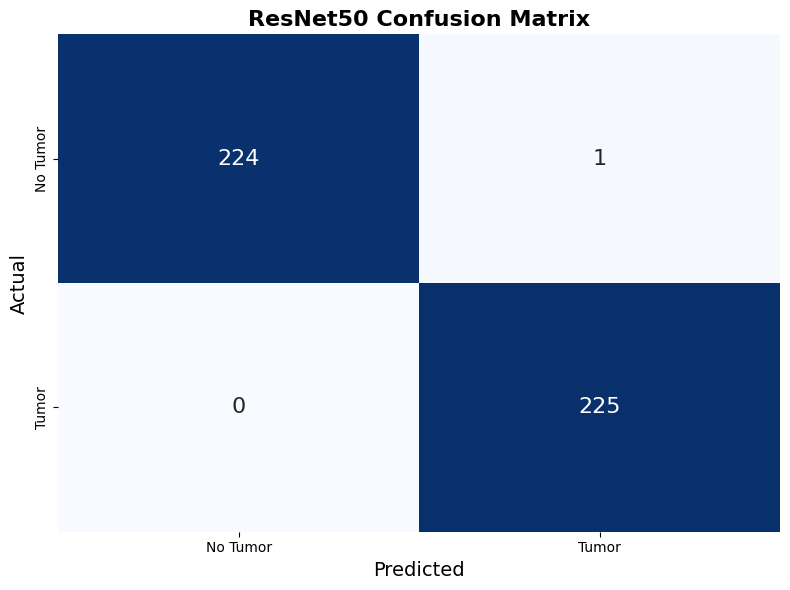

Saved: confusion_matrix_resnet50.png


In [22]:
# SimpleCNN Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(simplecnn_results['confusion_matrix'], annot=True, fmt='d', 
            cmap='Greens', cbar=False,
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'],
            annot_kws={'size': 16})
plt.title('SimpleCNN Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_simplecnn.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_simplecnn.png")

# ResNet50 Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(resnet50_results['confusion_matrix'], annot=True, fmt='d', 
            cmap='Blues', cbar=False,
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'],
            annot_kws={'size': 16})
plt.title('ResNet50 Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix_resnet50.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix_resnet50.png")

## 10. Visualization: Accuracy Comparison

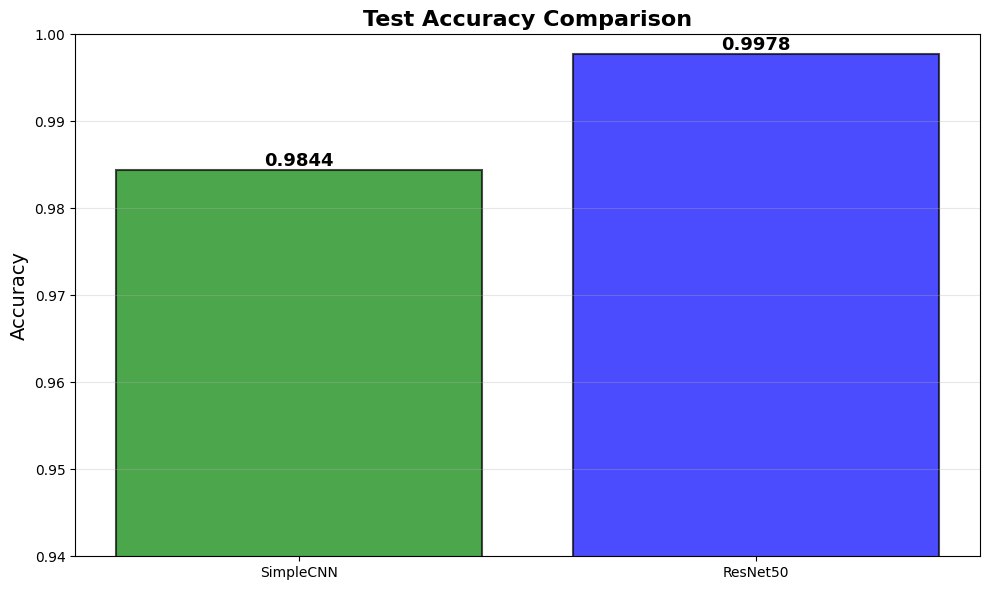

Saved: accuracy_comparison.png


In [23]:
plt.figure(figsize=(10, 6))
models = ['SimpleCNN', 'ResNet50']
accuracies = [simplecnn_results['accuracy'], resnet50_results['accuracy']]
colors = ['green', 'blue']
bars = plt.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Test Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylim([0.94, 1.0])
plt.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: accuracy_comparison.png")

## 11. Visualization: AUC Comparison

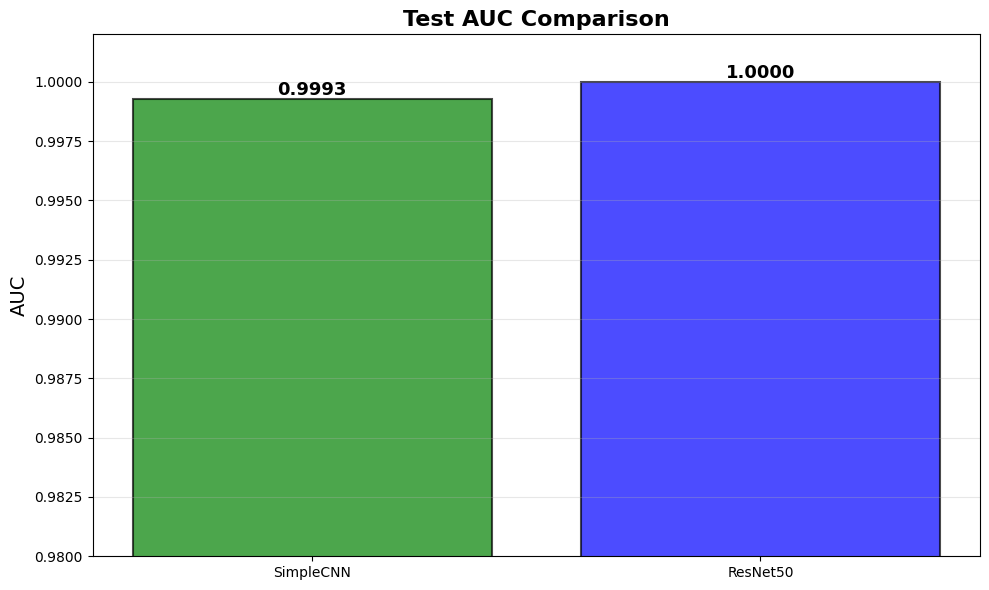

Saved: auc_comparison.png


In [24]:
plt.figure(figsize=(10, 6))
aucs = [simplecnn_results['auc'], resnet50_results['auc']]
bars = plt.bar(models, aucs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
plt.ylabel('AUC', fontsize=14)
plt.title('Test AUC Comparison', fontsize=16, fontweight='bold')
plt.ylim([0.98, 1.002])
plt.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('auc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: auc_comparison.png")

## 12. Visualization: Performance Metrics Breakdown

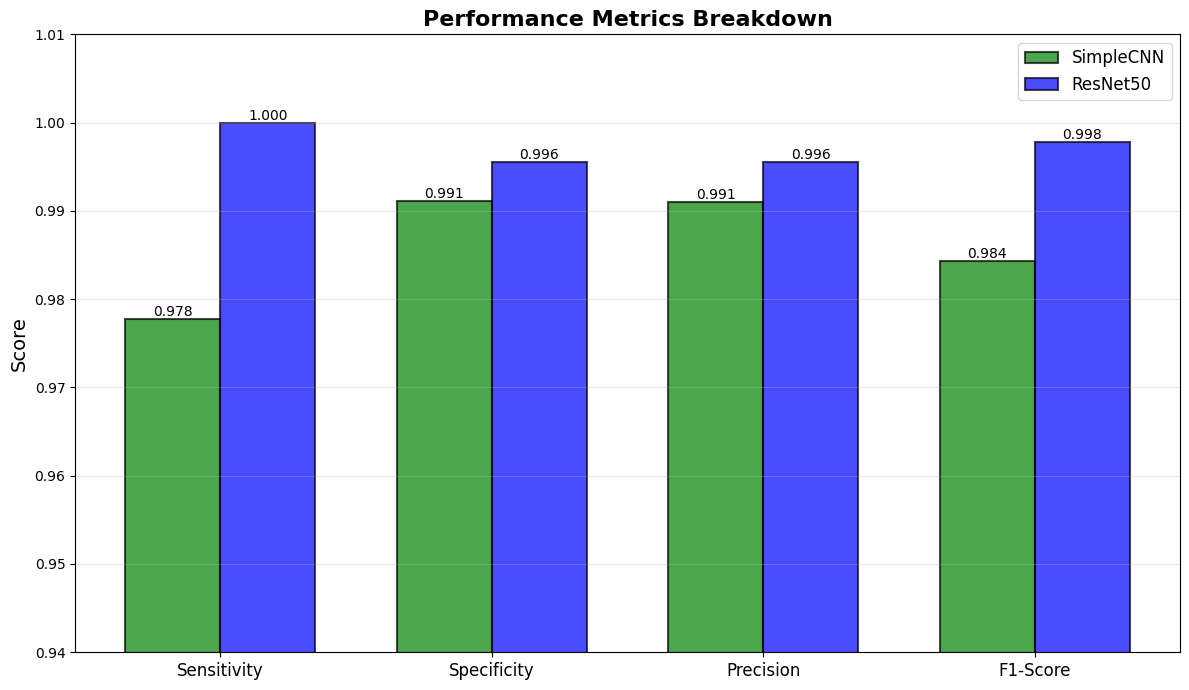

Saved: metrics_breakdown.png


In [25]:
plt.figure(figsize=(12, 7))
x = np.arange(4)
width = 0.35
metrics_labels = ['Sensitivity', 'Specificity', 'Precision', 'F1-Score']

simplecnn_metrics = [simplecnn_results['sensitivity'], simplecnn_results['specificity'], 
                     simplecnn_results['precision'], simplecnn_results['f1']]
resnet50_metrics = [resnet50_results['sensitivity'], resnet50_results['specificity'], 
                    resnet50_results['precision'], resnet50_results['f1']]

bars1 = plt.bar(x - width/2, simplecnn_metrics, width, label='SimpleCNN', 
                color='green', alpha=0.7, edgecolor='black', linewidth=1.5)
bars2 = plt.bar(x + width/2, resnet50_metrics, width, label='ResNet50', 
                color='blue', alpha=0.7, edgecolor='black', linewidth=1.5)

plt.ylabel('Score', fontsize=14)
plt.title('Performance Metrics Breakdown', fontsize=16, fontweight='bold')
plt.xticks(x, metrics_labels, fontsize=12)
plt.legend(fontsize=12)
plt.ylim([0.94, 1.01])
plt.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('metrics_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: metrics_breakdown.png")

---

## Summary

Comparison complete. All outputs saved to current directory (comparison/):

**CSV Output:**
- model_comparison_metrics.csv - Comprehensive comparison table

**Visualization Outputs:**
- roc_curve_comparison.png - ROC curves overlay
- confusion_matrix_simplecnn.png - SimpleCNN confusion matrix
- confusion_matrix_resnet50.png - ResNet50 confusion matrix
- accuracy_comparison.png - Accuracy bar chart
- auc_comparison.png - AUC bar chart
- metrics_breakdown.png - Sensitivity, specificity, precision, F1-score comparison

**Key Findings:**
- Both models achieve excellent performance on this test set
- ResNet50 shows marginally higher metrics but at significantly higher complexity
- SimpleCNN provides strong performance with 36x fewer parameters
- Deployment decision depends on production constraints and validation requirements

**Next Steps:**
1. Apply Grad-CAM to both models for interpretability analysis
2. Verify models focus on tumor regions (not artifacts)
3. Make final deployment recommendation based on validation evidence